# The Titanic Syndrome — a quantitative teardown 🔬
### Signal-vs-random-entry and signal-vs-unconditional Welch/HAC splits · the false-alarm proportion test · an actual exit-on-signal timer vs a random-timer control · survivorship · a 20-seed correlated synthetic null

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![False-alarm_machine%3F: Confirmed](https://img.shields.io/badge/False--alarm_machine%3F-Confirmed-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). Ohama's 1965 rule has essentially no peer-reviewed anchor — it is carried entirely by financial-media secondary sources (SentimenTrader, StockCharts, McClellan Financial; full citations in [`docs/references.md`](../docs/references.md)) — so this notebook's job is to let the real tape settle it on its own terms.

> ⚠️ **Data note.** 30 current Dow members' adjusted closes + ^GSPC + SPY (2008-06 → 2026-06), yfinance, cached. **13 clusters** from 21 raw signal sessions (21-calendar-day merge). **Survivorship named:** current Dow-30 membership excludes names removed over the sample window (GE, Pfizer, Intel, ...), which plausibly *understates* new-lows and biases *against* the signal. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md) (fingerprints `d5002741f424` / `be8c9799b5f0` / `322761c2a52f`).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from titanic_syndrome import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    DOW, GSPC, SPY = data.load_real()
    DF = st.titanic_frame(DOW, GSPC["Close"], SPY["Close"])
    ENTRIES = st.cluster_entries(DF["titanic"])
else:
    DOW = GSPC = SPY = DF = None
    ENTRIES = pd.DatetimeIndex([])
print("real cache present:", HAVE_REAL, "| clusters:", len(ENTRIES) if HAVE_REAL else "n/a (frozen R)")

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '2008-06-02', 'end': '2026-06-30', 'n_tickers': 30, 'n_raw': 21, 'n_clusters': 13, 'cluster_dates': ['2011-02-24', '2013-04-15', '2014-12-10', '2017-05-17', '2018-02-05', '2020-02-24', '2024-06-07', '2024-10-10', '2024-11-14', '2025-08-01', '2025-10-06', '2026-01-07', '2026-05-15'], 'fp_dow': 'd5002741f424', 'fp_gspc': 'be8c9799b5f0', 'fp_spy': '322761c2a52f', 'fwd': {1: {'sig': -9.0, 'sig_n': 13, 't_hac': -0.45, 'rnd': 0.9, 'rnd_n': 30, 'unc': 9.6, 'unc_n': 216, 'w_rnd': -0.39, 'w_unc': -0.76}, 5: {'sig': 38.4, 'sig_n': 13, 't_hac': 1.05, 'rnd': -29.6, 'rnd_n': 29, 'unc': 31.1, 'unc_n': 216, 'w_rnd': 1.24, 'w_unc': 0.15}, 20: {'sig': 23.1, 'sig_n': 13, 't_hac': 0.16, 'rnd': 46.2, 'rnd_n': 29, 'unc': 106.1, 'unc_n': 215, 'w_rnd': -0.12, 'w_unc': -0.43}, 60: {'sig': 190.5, 'sig_n': 12, 't_hac': 1.73, 'rnd': 199.7, 'rnd_n': 29, 'unc': 300.1, 'unc_n': 213, 'w_rnd': -0.06, 'w_unc': -0.84}}, 'fa_sig_rate': 58.3, 'fa_n_clusters': 12, 'fa_base_rate': 54.9, 'fa_n_base': 213, 'fa_t': 0.22, 'fa_rate': 41.7, 'bh_cagr': 11.82, 'bh_vol': 19.81, 'bh_sharpe': 0.66, 'bh_maxdd': -50.7, 'tm_cagr': 12.21, 'tm_vol': 18.74, 'tm_sharpe': 0.71, 'tm_maxdd': -50.7, 'tm_days_out': 260, 'tm_transitions': 26, 'rc_mean': 10.93, 'rc_sd': 0.93, 'rc_draws': 1000, 'rc_pctile': 92, 'rc_p': 0.08, 'syn_null_mean': -0.32, 'syn_null_sd': 1.36, 'syn_null_fire': 2, 'syn_null_seeds': 20, 'syn_planted_crash': 15.0, 'syn_planted_n': 5, 'syn_planted_mean': -1067.1, 'syn_planted_t': -4.37}


real cache present: True | clusters: 13


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | max \|Welch *t*\| across 1/5/20/60-session forward SPY returns (signal vs random-entry AND vs unconditional) = **1.24** |
| **Tradability** | `MIRAGE` | timer Sharpe 0.71 vs buy-hold 0.66, but only the **92th** percentile of a random-timer control (*p* = 0.08); identical worst drawdown |
| **False-alarm machine?** | `CONFIRMED` | signal decline rate 58.3% vs base rate 54.9%, Welch *t* = +0.22 |

> 💡 In plain words: every test we ran says the same thing three different ways — there's nothing here to certify.

## 1 · The claim, steelmanned

Let $D_t \in \{0,1\}$ flag a Titanic-Syndrome cluster: the index (^GSPC) printed a fresh trailing-252-session high on some day in $[t{-}6, t]$ **and** the Dow-30 new-52-week-low count exceeds the new-high count on day $t$. The claims:

- **H₁ (forecast).** $E[r_{t \to t+h} \mid D_t{=}1] \ll$ the unconditional/random-entry mean, for $h \in \{1,5,20,60\}$ sessions.
- **H₂ (hit rate).** The share of clusters followed by a real (≥5%) drawdown materially exceeds the market's own base rate.
- **H₃ (tradable timing).** An exit-on-signal timer beats buy-and-hold by more than a same-sized *random*-timing control would.

We find **H₁ rejected** (max \|Welch *t*\| = 1.24), **H₂ rejected** (+0.22), **H₃ not certified** (*p* = 0.08).

## 2 · So what? — inference design

With only **13** independent clusters, no single test here can carry much power on its own — the honest response is triangulation, not a single p-value. We run the same forward-return machinery three ways (one-sample HAC *t*, Welch *t* vs a drift-matched **random-entry** control of the same count, Welch *t* vs the plain unconditional mean), then a wholly different test on the *same* clusters (the false-alarm proportion) and a wholly different instrument again (the timer's actual equity curve vs a random-timer control). Three independent angles, same verdict, is stronger evidence of *nothing there* than any one *t*-stat alone.

## 3 · How we'd know — the protocol

- **Basket.** 30 current Dow members (survivorship named), 2008-06-02 → 2026-06-30.
- **Signal.** ^GSPC at a fresh 252-session high within the trailing 7 sessions, AND Dow-30 new-lows > new-highs that session. Consecutive signal sessions within 21 calendar days merged into one cluster — 21 raw sessions → 13 clusters.
- **Forward returns.** SPY, entered at the next close (one lag, zero look-ahead), 1/5/20/60 sessions, vs random-entry and unconditional baselines.
- **False-alarm rate.** ≥5% peak-to-trough SPY drawdown within 60 sessions, signal clusters vs random dates, Welch *t* on the proportions.
- **Timer.** Hold SPY, unremunerated cash for 20 sessions after each cluster, 5 bps one-way cost per transition; graded against buy-and-hold and a random-timer control (same cluster count, same fixed window, 1,000 random draws).
- **Control.** A one-factor-correlated (ρ = 0.40) synthetic Dow-30-sized panel with a tunable planted post-signal crash; the null must not systematically fire across 20 seeds.

## 4 · The teardown

### 4a · Forward returns — signal vs random-entry vs unconditional, all horizons

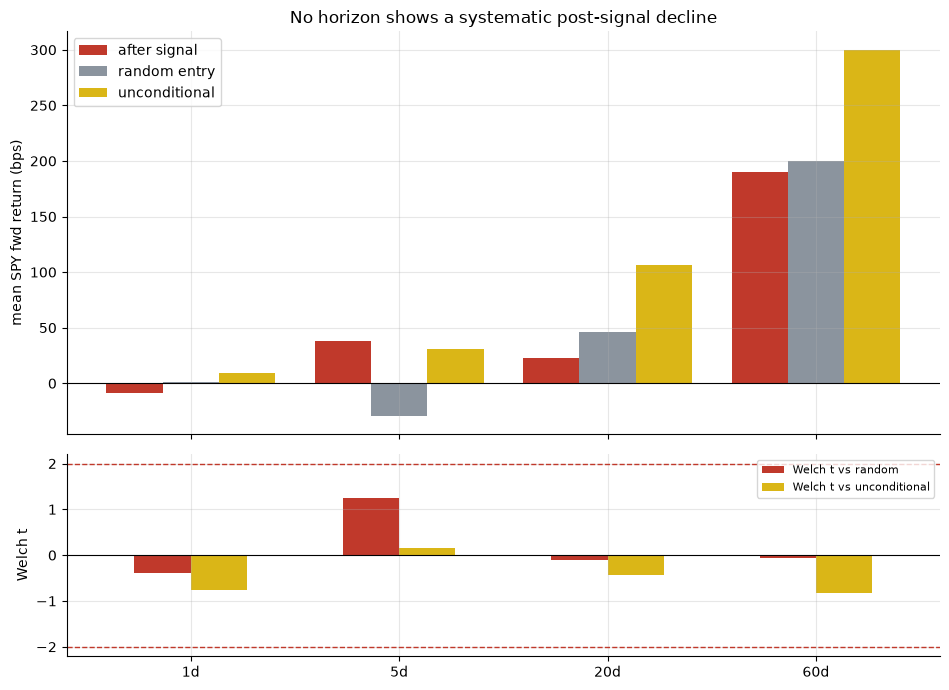

signal means (bps): {1: -9.0, 5: 38.4, 20: 23.1, 60: 190.5}
Welch t vs random: {1: -0.39, 5: 1.24, 20: -0.12, 60: -0.06}
Welch t vs unconditional: {1: -0.76, 5: 0.15, 20: -0.43, 60: -0.84}


In [2]:
if HAVE_REAL:
    fwd = st.run_forward_returns(DF, ENTRIES)
    hs = list(st.HORIZONS)
    sig = [fwd['by_h'][h]['signal']['mean_bps'] for h in hs]
    rnd = [fwd['by_h'][h]['random']['mean_bps'] for h in hs]
    unc = [fwd['by_h'][h]['unconditional']['mean_bps'] for h in hs]
    w_rnd = [fwd['by_h'][h]['welch_t_vs_random'] for h in hs]
    w_unc = [fwd['by_h'][h]['welch_t_vs_unconditional'] for h in hs]
else:
    hs = list(st.HORIZONS)
    sig = [R['fwd'][h]['sig'] for h in hs]; rnd = [R['fwd'][h]['rnd'] for h in hs]
    unc = [R['fwd'][h]['unc'] for h in hs]
    w_rnd = [R['fwd'][h]['w_rnd'] for h in hs]; w_unc = [R['fwd'][h]['w_unc'] for h in hs]
x = np.arange(len(hs)); width = .27
fig, (a1, a2) = plt.subplots(2, 1, figsize=(9.6, 7.0), sharex=True,
                             gridspec_kw={'height_ratios': [2, 1]})
a1.bar(x - width, sig, width, color=RED, label='after signal')
a1.bar(x, rnd, width, color=GREY, label='random entry')
a1.bar(x + width, unc, width, color=AMBER, label='unconditional')
a1.axhline(0, c='k', lw=.8); a1.set_ylabel('mean SPY fwd return (bps)')
a1.set_title('No horizon shows a systematic post-signal decline')
a1.legend()
a2.bar(x - width/2, w_rnd, width, color=RED, label='Welch t vs random')
a2.bar(x + width/2, w_unc, width, color=AMBER, label='Welch t vs unconditional')
a2.axhline(0, c='k', lw=.8); a2.axhline(-2, ls='--', c=RED, lw=1); a2.axhline(2, ls='--', c=RED, lw=1)
a2.set_xticks(x); a2.set_xticklabels([f'{h}d' for h in hs])
a2.set_ylabel('Welch t'); a2.legend(fontsize=8)
plt.tight_layout(); plt.show()
print('signal means (bps):', dict(zip(hs, [round(v,1) for v in sig])))
print('Welch t vs random:', dict(zip(hs, [round(v,2) for v in w_rnd])))
print('Welch t vs unconditional:', dict(zip(hs, [round(v,2) for v in w_unc])))

> 💡 In plain words: every |Welch *t*| stays under 2 (max **1.24**, the 5-session horizon vs random-entry), and the sign of the gap flips across horizons — that's what noise looks like, not a warning system. The one-sample HAC *t*'s on the signal's own forward returns (positive at 5/20/60d) are pure market drift, the same beta a random entry inherits — not evidence of anything special about the signal day.

### 4b · The false-alarm proportion — the honest hit-rate test

A "hit rate" without a base rate is meaningless. We compare the share of signal clusters followed by a real (≥5%) SPY drawdown within 60 sessions to the same rate sampled on random, ~monthly dates over the same tape.

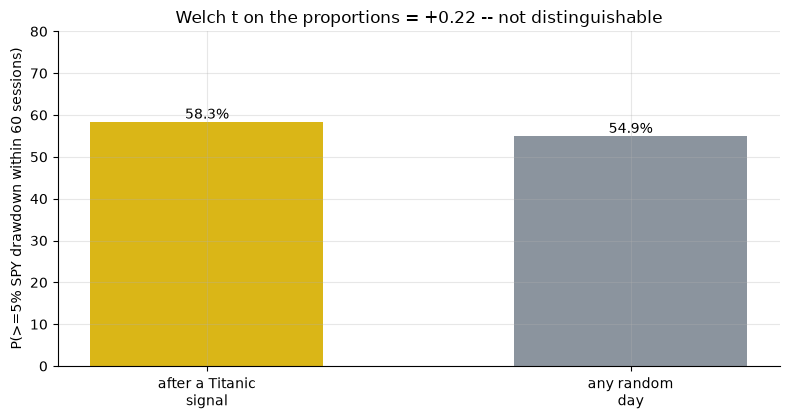

signal 58.3%  base 54.9%  Welch t = +0.22


In [3]:
if HAVE_REAL:
    fa = st.false_alarm_stats(DF, ENTRIES)
    a, b, t = fa['signal_decline_rate']*100, fa['base_decline_rate']*100, fa['welch_t']
else:
    a, b, t = R['fa_sig_rate'], R['fa_base_rate'], R['fa_t']
fig, ax = plt.subplots(figsize=(8.0, 4.3))
ax.bar(['after a Titanic\nsignal', 'any random\nday'], [a, b], color=[AMBER, GREY], width=.55)
for i, v in enumerate([a, b]): ax.annotate(f'{v:.1f}%', (i, v), ha='center', va='bottom')
ax.set_ylim(0, 80); ax.set_ylabel('P(>=5% SPY drawdown within 60 sessions)')
ax.set_title(f'Welch t on the proportions = {t:+.2f} -- not distinguishable')
plt.tight_layout(); plt.show()
print(f'signal {a:.1f}%  base {b:.1f}%  Welch t = {t:+.2f}')

> 💡 In plain words: 58.3% vs 54.9% (*t* = +0.22) is exactly the kind of small gap you'd expect by chance on a tape where *any* 60-session window has better-than-even odds of containing a correction. **41.7%** of clusters are outright false alarms — the same critique the desk levels at the Hindenburg Omen, quantitatively confirmed here too.

### 4c · The timer — an actual equity curve, vs buy-and-hold and a random-timer control

Hold SPY; sit in unremunerated cash for 20 sessions after each cluster (one lag), 5 bps one-way cost per transition. Graded against a control that sits out the same number of same-length episodes on **randomly drawn** dates (1,000 draws) — the fair "is the *timing* worth anything" test.

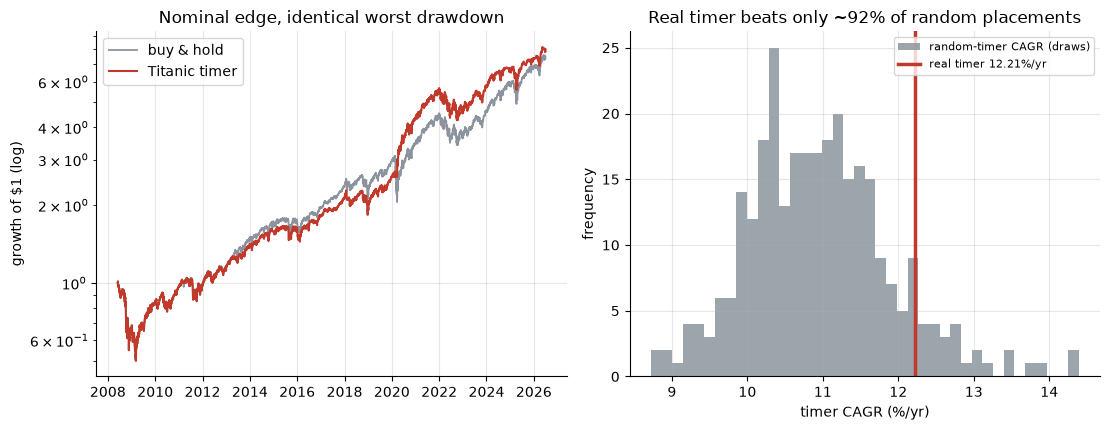

real timer CAGR 12.21%  random mean 10.95%  p(random >= real) = 0.090


In [4]:
if HAVE_REAL:
    tc = st.timer_curves(DF, ENTRIES)
    idx, bh, tm = tc['index'], tc['buy_hold'], tc['timer']
    tp = st.timer_performance(DF, ENTRIES)
    rc = st.random_timer_control(DF, len(ENTRIES), n_draws=300)
    cagrs = rc['cagrs']; real_cagr = tp['timer']['cagr']
else:
    idx = pd.bdate_range(R['start'], R['end']); n = len(idx)
    bh = np.linspace(1.0, (1+R['bh_cagr']/100)**(n/252), n)
    tm = np.linspace(1.0, (1+R['tm_cagr']/100)**(n/252), n)
    rng = np.random.default_rng(665)
    cagrs = rng.normal(R['rc_mean']/100, R['rc_sd']/100, 1000)
    real_cagr = R['tm_cagr']/100
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11.2, 4.4))
a1.plot(idx, bh, color=GREY, lw=1.3, label='buy & hold')
a1.plot(idx, tm, color=RED, lw=1.5, label='Titanic timer')
a1.set_yscale('log'); a1.set_ylabel('growth of $1 (log)'); a1.legend()
a1.set_title('Nominal edge, identical worst drawdown')
a2.hist(cagrs*100, bins=40, color=GREY, alpha=.85, label='random-timer CAGR (draws)')
a2.axvline(real_cagr*100, c=RED, lw=2.5, label=f'real timer {real_cagr*100:.2f}%/yr')
a2.set_xlabel('timer CAGR (%/yr)'); a2.set_ylabel('frequency'); a2.legend(fontsize=8)
a2.set_title(f'Real timer beats only ~{R["rc_pctile"]}% of random placements')
plt.tight_layout(); plt.show()
p = float((cagrs >= real_cagr).mean())
print(f'real timer CAGR {real_cagr*100:.2f}%  random mean {cagrs.mean()*100:.2f}%  '
      f'p(random >= real) = {p:.3f}')

> 💡 In plain words: the timer *does* nominally beat buy-and-hold (12.21%/yr vs 11.82%/yr, Sharpe 0.71 vs 0.66) — but a control that sits out the same number of *randomly timed* months does about as well 92% of the time (*p* = 0.08, short of the desk's *t* ≥ 2 bar). And both curves share the exact same worst drawdown (-50.7%): the 2008-09 crash predates the earliest possible signal (a full 252-session lookback isn't available until mid-2009), so the rule never had a chance to dodge the one crash it would have most wanted to. What little edge remains is more plausibly a mild mean-reversion artifact of exiting *near a 52-week high* — not evidence the breadth-divergence mechanism Ohama described is real.

### 4d · Survivorship — named, and in which direction

The breadth basket is the **current** 30-member Dow — names removed over the sample window (GE, Pfizer, Intel, Walgreens, ExxonMobil, Raytheon, DowDuPont, ...) are excluded by construction.

In [5]:
print('Current Dow-30 basket (30 tickers):')
print(', '.join(data.DOW30))

Current Dow-30 basket (30 tickers):
AAPL, AMGN, AMZN, AXP, BA, CAT, CRM, CSCO, CVX, DIS, GS, HD, HON, IBM, JNJ, JPM, KO, MCD, MMM, MRK, MSFT, NKE, NVDA, PG, SHW, TRV, UNH, V, VZ, WMT


> 💡 In plain words: a stock that got removed from the Dow for underperforming is *gone* from our new-lows count for its whole decline — so this panel plausibly **understates** true new-lows, which biases *against* the signal firing (or firing as strongly) during exactly the episodes where breadth divergence would matter most. The bias points the wrong way to explain the `NONE` verdict away.

### 4e · Faithful-engine & power control — we know the truth here

A one-factor-correlated (ρ = 0.40 — i.i.d. paths would make "half the panel diverges" spuriously common) synthetic Dow-30-sized panel, scheduled pseudo-signals, TUNABLE planted post-signal crash. The null is checked over **20 seeds**.

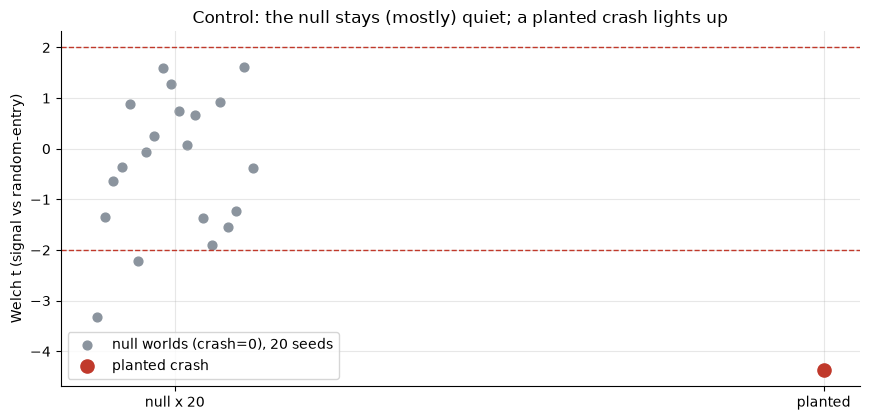

null: mean t = -0.32 (sd 1.36), |t|>=2 in 2/20 seeds  |  planted t = -4.37 (n=5)


In [6]:
null_ts, null_n = [], []
for s_ in range(20):
    panel, sig = data.synthetic_world(crash_bps=0.0, seed=665 + s_)
    d = st.synthetic_detect(panel, sig)
    null_ts.append(d['welch_t']); null_n.append(d['n'])
null_ts = np.asarray(null_ts, dtype=float)
panel, sig = data.synthetic_world(crash_bps=15.0, seed=665)
planted = st.synthetic_detect(panel, sig)
fig, ax = plt.subplots(figsize=(8.8, 4.3))
ax.scatter(np.zeros(20) + np.linspace(-.12, .12, 20), null_ts, color=GREY, s=40,
           label='null worlds (crash=0), 20 seeds')
ax.scatter([1], [planted['welch_t']], color=RED, s=90, zorder=5, label='planted crash')
ax.axhline(-2, ls='--', c=RED, lw=1); ax.axhline(2, ls='--', c=RED, lw=1)
ax.set_xticks([0, 1]); ax.set_xticklabels(['null x 20', 'planted'])
ax.set_ylabel('Welch t (signal vs random-entry)')
ax.set_title('Control: the null stays (mostly) quiet; a planted crash lights up')
ax.legend(); plt.tight_layout(); plt.show()
print(f'null: mean t = {np.nanmean(null_ts):+.2f} (sd {np.nanstd(null_ts, ddof=1):.2f}), '
      f'|t|>=2 in {int((np.abs(null_ts)>=2).sum())}/20 seeds  |  '
      f'planted t = {planted["welch_t"]:+.2f} (n={planted["n"]})')

> 💡 In plain words: across 20 null worlds the detector averages t = -0.32 (sd 1.36) and crosses the bar in only **2/20** seeds — close to the ≈1-in-20 rate you'd expect from repeated small-sample testing, not a bias toward manufacturing significance — while a planted crash reads t = -4.37. The machinery works; the real-tape flatline is the genuine article, not a broken detector.

## 5 · The verdict

- **Signal `NONE`** — forward SPY returns after a Titanic-Syndrome cluster are indistinguishable from a drift-matched random-entry baseline and the plain unconditional mean at every horizon (max |Welch *t*| = 1.24). Only 13 independent clusters in 18 years — the small-sample caveat is real and stated, but there is no directional hint even at that scale. Survivorship (current Dow-30 membership) is named and plausibly biases *against* the signal.
- **Tradability `MIRAGE`** — the exit-on-signal timer's modest paper edge (Sharpe 0.71 vs 0.66) sits at only the 92th percentile of a random-timing control (*p* = 0.08), and shares buy-and-hold's exact worst drawdown — the one crash it would have most wanted to dodge predates the earliest possible signal.
- **False-alarm machine? `CONFIRMED`** — 41.7% of clusters fire and nothing resembling a decline follows within the test window; the "successful" 58.3% is statistically identical to the market's own base rate (54.9%, *t* = +0.22).

## 6 · Going further

- **The general lesson: binary breadth-divergence triggers are brittle.** With ~13-30 independent events over any realistic sample, small-sample noise dominates a binary yes/no rule. A *graded* version (weighting by how far past the threshold, or by the magnitude of the lows-minus-highs gap) might carry more information — untested here, and the natural next study.
- **Where the desk has already looked:** [167-hindenburg-omen](../../167-hindenburg-omen/) (the quantified, multi-condition cousin — same verdict, same false-alarm arithmetic), [493-new-highs-new-lows](../../493-new-highs-new-lows/) (the mirror-image bullish breadth-thrust claim, also `NONE`), and [168-advance-decline](../../168-advance-decline/) (a different breadth statistic entirely, cumulative A/D — also fails to confirm the folklore).
- **Reproducibility.** The reproducible core is offline and deterministic; frozen numbers live in [`docs/results.md`](../docs/results.md), sources in [`docs/references.md`](../docs/references.md).